# Model Comparison: Competition vs Asymmetric Feedback

This notebook compares the two models:
1. **Competition model:** Proteins compete for limiting import factor
2. **Asymmetric feedback model:** Rectified transcriptional regulation

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from models import (
    integrate_competition_to_steady_state,
    simulate_competition_trajectory,
    integrate_feedback_to_steady_state,
    simulate_feedback_trajectory,
)
from utils import load_parameters

warnings.filterwarnings("ignore")

# Plotting style
plt.rcParams.update(
    {"figure.figsize": (14, 6), "font.size": 11, "font.family": "Arial"}
)

## Load Fitted Parameters

In [2]:
# Load fitted parameters from both models
comp_params = load_parameters("fitted_parameters/competition_params_manual.json")
fb_params = load_parameters("fitted_parameters/feedback_params_manual.json")

print("Competition model parameters:")
for key, val in comp_params.items():
    print(f"  {key}: {val:.6f}" if isinstance(val, float) else f"  {key}: {val}")

print("\nFeedback model parameters:")
for key, val in fb_params.items():
    print(f"  {key}: {val:.6f}" if isinstance(val, float) else f"  {key}: {val}")

Competition model parameters:
  k_s: 0.115240
  k_import: 2.230000
  F_total: 0.075500
  K_D: 0.001460
  delta_f_A: 0.280000
  delta_n_A: 0.135228
  delta_n_B_factor: 1.443294

Feedback model parameters:
  k_s_max: 0.370000
  S: 0.300000
  Total_ref: 1.014700
  delta_A_base: 0.135228
  delta_B_base: 0.195174
  delta_B_extra: 1.884268


## Setup Simulation Conditions

In [3]:
# Simulation settings
PLOT_DURATION = 24.0  # hours
NEGATIVE_LEAD = 2.0  # hours before perturbation
N_POINTS = 200

# Normalization factors
RFP_NORM = 0.5994
GFP_NORM = 0.4153

# Fixed degradation parameters (from competition model)
DELTA_N_A = comp_params["delta_n_A"]
DELTA_N_B_FACTOR = comp_params["delta_n_B_factor"]
DELTA_DELTA = np.log(2) / 0.33 - DELTA_N_A

print(f"Simulation duration: {PLOT_DURATION} hours")
print(f"Delta perturbation: {DELTA_DELTA:.4f} hr⁻¹")

Simulation duration: 24.0 hours
Delta perturbation: 1.9652 hr⁻¹


## Generate Competition Model Trajectories

In [4]:
# Calculate degradation rates for competition model
delta_f_A = comp_params["delta_f_A"]
delta_f_B_control = delta_f_A
delta_f_B_perturbed = delta_f_A + DELTA_DELTA
delta_n_B_control = DELTA_N_B_FACTOR * DELTA_N_A
delta_n_B_perturbed = DELTA_N_B_FACTOR * DELTA_N_A + DELTA_DELTA

# Calculate steady states
comp_ss_control = integrate_competition_to_steady_state(
    comp_params, delta_f_B_control, DELTA_N_A, delta_n_B_control
)
comp_ss_perturbed = integrate_competition_to_steady_state(
    comp_params, delta_f_B_perturbed, DELTA_N_A, delta_n_B_perturbed
)

print("Competition model steady states:")
print(f"  Control:   A_n={comp_ss_control[2]:.3f}, B_n={comp_ss_control[3]:.3f}")
print(f"  Perturbed: A_n={comp_ss_perturbed[2]:.3f}, B_n={comp_ss_perturbed[3]:.3f}")

# Simulate trajectories
comp_trajectories = {}

# VEH_AUX: control → perturbed
traj, times = simulate_competition_trajectory(
    comp_params,
    delta_f_B_perturbed,
    DELTA_N_A,
    delta_n_B_perturbed,
    PLOT_DURATION,
    comp_ss_control,
    n_points=N_POINTS,
)
comp_trajectories["VEH_AUX"] = {"time": times, "A_n": traj[2], "B_n": traj[3]}

# AUX_VEH: perturbed → control
traj, times = simulate_competition_trajectory(
    comp_params,
    delta_f_B_control,
    DELTA_N_A,
    delta_n_B_control,
    PLOT_DURATION,
    comp_ss_perturbed,
    n_points=N_POINTS,
)
comp_trajectories["AUX_VEH"] = {"time": times, "A_n": traj[2], "B_n": traj[3]}

print("\nGenerated competition trajectories")

Competition model steady states:
  Control:   A_n=0.619, B_n=0.429
  Perturbed: A_n=0.767, B_n=0.028

Generated competition trajectories


## Generate Feedback Model Trajectories

In [5]:
# Extract feedback parameters
k_s_max = fb_params["k_s_max"]
S = fb_params["S"]
Total_ref = fb_params["Total_ref"]
delta_A = fb_params["delta_A_base"]
delta_B_control = fb_params["delta_B_base"]
delta_B_perturbed = fb_params["delta_B_base"] + fb_params["delta_B_extra"]

# Calculate steady states
fb_ss_control = integrate_feedback_to_steady_state(
    k_s_max, S, Total_ref, delta_A, delta_B_control
)
fb_ss_perturbed = integrate_feedback_to_steady_state(
    k_s_max, S, Total_ref, delta_A, delta_B_perturbed
)

print("Feedback model steady states:")
print(f"  Control:   A={fb_ss_control[0]:.3f}, B={fb_ss_control[1]:.3f}")
print(f"  Perturbed: A={fb_ss_perturbed[0]:.3f}, B={fb_ss_perturbed[1]:.3f}")

# Simulate trajectories
fb_trajectories = {}

# VEH_AUX: control → perturbed
traj, times = simulate_feedback_trajectory(
    k_s_max,
    S,
    Total_ref,
    delta_A,
    delta_B_perturbed,
    PLOT_DURATION,
    fb_ss_control,
    n_points=N_POINTS,
)
fb_trajectories["VEH_AUX"] = {"time": times, "A_n": traj[0], "B_n": traj[1]}

# AUX_VEH: perturbed → control
traj, times = simulate_feedback_trajectory(
    k_s_max,
    S,
    Total_ref,
    delta_A,
    delta_B_control,
    PLOT_DURATION,
    fb_ss_perturbed,
    n_points=N_POINTS,
)
fb_trajectories["AUX_VEH"] = {"time": times, "A_n": traj[0], "B_n": traj[1]}

print("\nGenerated feedback trajectories")

Feedback model steady states:
  Control:   A=0.624, B=0.433
  Perturbed: A=0.748, B=0.049

Generated feedback trajectories


## Publication-Quality Compact Comparison

This section creates the key publication figure showing both models overlaid with experimental data.

In [ ]:
# Load experimental data for overlay
from utils import load_experimental_data, calculate_time_averages

data_path = Path(
    "/Users/z3532965/src/publications/2026_POLR2A_homeostasis/Modelling/data/mACmCh_LiveCellWashout_Values_ByExperiment.csv"
)
data = load_experimental_data(data_path, {"RFP": RFP_NORM, "GFP": GFP_NORM})

# Calculate time-averaged data
fit_conditions = ["VEH_AUX", "AUX_VEH"]
data_averaged = calculate_time_averages(data, fit_conditions)

# Use only first 12 hours
FIT_MAX_HOURS = 12.0
for code in fit_conditions:
    data_averaged[code] = data_averaged[code][
        data_averaged[code]["time"] <= FIT_MAX_HOURS
    ]

print(f"Loaded experimental data for: {list(data_averaged.keys())}")

Loaded experimental data for: ['VEH_AUX', 'AUX_VEH']


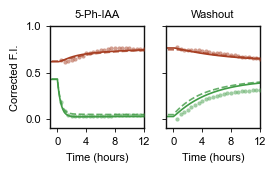

Saved publication figure to /Users/z3532965/src/publications/2026_POLR2A_homeostasis/Modelling/abundance_homeostasis/model_comparison_publication.pdf


In [7]:
# Create publication-quality compact comparison figure

# Publication colors
color_gfp = "#419c46"
color_mcherry = "#a73f23"

# Create compact figure for publication
fig, axes = plt.subplots(1, 2, figsize=(2.8, 1.77), sharey=True)
fig.subplots_adjust(wspace=-1.5)
plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 8

conditions_pub = [("VEH_AUX", "5-Ph-IAA"), ("AUX_VEH", "Washout")]

for idx, (ax, (code, title)) in enumerate(zip(axes, conditions_pub)):
    ax.set_facecolor("white")

    # Negative lead time
    neg_times = np.linspace(-NEGATIVE_LEAD, 0, 20)

    # Get competition trajectories
    comp_traj = comp_trajectories[code]
    A_n_comp_0 = comp_traj["A_n"][0]
    B_n_comp_0 = comp_traj["B_n"][0]
    A_neg_comp = np.full_like(neg_times, A_n_comp_0)
    B_neg_comp = np.full_like(neg_times, B_n_comp_0)
    time_comp = np.concatenate([neg_times, comp_traj["time"]])
    A_comp_full = np.concatenate([A_neg_comp, comp_traj["A_n"]])
    B_comp_full = np.concatenate([B_neg_comp, comp_traj["B_n"]])

    # Get feedback trajectories
    fb_traj = fb_trajectories[code]
    A_n_fb_0 = fb_traj["A_n"][0]
    B_n_fb_0 = fb_traj["B_n"][0]
    A_neg_fb = np.full_like(neg_times, A_n_fb_0)
    B_neg_fb = np.full_like(neg_times, B_n_fb_0)
    time_fb = np.concatenate([neg_times, fb_traj["time"]])
    A_fb_full = np.concatenate([A_neg_fb, fb_traj["A_n"]])
    B_fb_full = np.concatenate([B_neg_fb, fb_traj["B_n"]])

    # Plot feedback model (dashed)
    ax.plot(
        time_fb, B_fb_full, color=color_gfp, linewidth=1.2, linestyle="--", alpha=0.8
    )
    ax.plot(
        time_fb,
        A_fb_full,
        color=color_mcherry,
        linewidth=1.2,
        linestyle="--",
        alpha=0.8,
    )

    # Plot competition model (solid)
    ax.plot(time_comp, B_comp_full, color=color_gfp, linewidth=1.2, linestyle="-")
    ax.plot(time_comp, A_comp_full, color=color_mcherry, linewidth=1.2, linestyle="-")

    # Add experimental data points
    if code in data_averaged:
        exp_data = data_averaged[code]

        # Plot RFP data
        ax.scatter(
            exp_data["time"],
            exp_data["rfp"],
            marker="o",
            s=9,
            color=color_mcherry,
            linewidth=0,
            alpha=0.5,
            zorder=3,
        )

        # Plot GFP data
        ax.scatter(
            exp_data["time"],
            exp_data["gfp"],
            marker="o",
            s=9,
            color=color_gfp,
            linewidth=0,
            alpha=0.5,
            zorder=3,
        )

    # Formatting
    ax.set_xlim(-1, 12)
    ax.set_ylim(-0.1, 1.0)
    ax.set_xticks([0, 4, 8, 12])
    ax.set_yticks([0.0, 0.5, 1.0])
    ax.tick_params(
        axis="both", which="both", direction="out", length=3.0, width=0.6, labelsize=8
    )
    ax.set_title(title, fontsize=8)
    ax.set_xlabel("Time (hours)", fontsize=8)

    if idx == 0:
        ax.set_ylabel("Corrected F.I.", fontsize=8)
    else:
        ax.set_ylabel("")

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.0)
        spine.set_color("#111111")

axes[0].set_xticklabels(["0", "4", "8", "12"])
axes[1].set_xticklabels(["0", "4", "8", "12"])

fig.tight_layout()

# Save to publication path
output_pub_path = Path("model_comparison_publication.pdf")
fig.savefig(output_pub_path, bbox_inches="tight")
plt.show()

print(f"Saved publication figure to {output_pub_path.resolve()}")

## Summary Statistics

In [8]:
print("\n" + "=" * 70)
print("MODEL COMPARISON SUMMARY")
print("=" * 70)

print("\n1. STEADY STATE COMPARISON")
print("-" * 70)
print(f"{'Condition':<20} {'Model':<15} {'A_n':<12} {'B_n':<12} {'Total':<12}")
print("-" * 70)

for condition, ss_label in [("Control", "control"), ("Perturbed", "perturbed")]:
    # Competition
    if ss_label == "control":
        comp_ss = comp_ss_control
        fb_ss = fb_ss_control
    else:
        comp_ss = comp_ss_perturbed
        fb_ss = fb_ss_perturbed

    comp_total = comp_ss[2] + comp_ss[3]
    fb_total = fb_ss[0] + fb_ss[1]

    print(
        f"{condition:<20} {'Competition':<15} {comp_ss[2]:<12.4f} {comp_ss[3]:<12.4f} {comp_total:<12.4f}"
    )
    print(
        f"{'':<20} {'Feedback':<15} {fb_ss[0]:<12.4f} {fb_ss[1]:<12.4f} {fb_total:<12.4f}"
    )
    print()

print("\n2. KEY DIFFERENCES")
print("-" * 70)
print("Competition Model:")
print("  - Proteins compete for limited import factor")
print("  - RFP buffering via competition dynamics")
print("  - 5 free parameters fitted to data")
print("\nFeedback Model:")
print("  - Rectified transcriptional feedback")
print("  - Only responds to protein depletion")
print("  - 2 free parameters fitted to data")
print("=" * 70)


MODEL COMPARISON SUMMARY

1. STEADY STATE COMPARISON
----------------------------------------------------------------------
Condition            Model           A_n          B_n          Total       
----------------------------------------------------------------------
Control              Competition     0.6185       0.4285       1.0471      
                     Feedback        0.6244       0.4326       1.0569      

Perturbed            Competition     0.7670       0.0282       0.7952      
                     Feedback        0.7483       0.0487       0.7970      


2. KEY DIFFERENCES
----------------------------------------------------------------------
Competition Model:
  - Proteins compete for limited import factor
  - RFP buffering via competition dynamics
  - 5 free parameters fitted to data

Feedback Model:
  - Rectified transcriptional feedback
  - Only responds to protein depletion
  - 2 free parameters fitted to data


## ARMC5 Comparison: Normal vs ARMC5 Conditions

This section compares both models (competition and feedback) under Normal vs ARMC5 knockdown conditions, where ARMC5 depletion increases protein half-life from ~7h to ~11.4h.

In [9]:
# ARMC5 condition: longer protein half-life (11.4h vs 7h)
# Load bleach chase data to calculate ARMC5 degradation rate
bleach_chase_path_armc5 = Path("../data/mACmCh_BleachChase_ByExperiment.csv")
bleach_chase_df_armc5 = pd.read_csv(bleach_chase_path_armc5, index_col=0)

# For ARMC5, use a fixed half-life of 11.4 hours (from literature/experiments)
HALFLIFE_ARMC5 = 11.4  # hours
DELTA_N_A_ARMC5 = np.log(2) / HALFLIFE_ARMC5 + np.log(2) / 19.75
DELTA_N_B_FACTOR_ARMC5 = DELTA_N_B_FACTOR  # Same ratio as Normal

print(f"ARMC5 condition parameters:")
print(f"  Half-life: {HALFLIFE_ARMC5:.1f} h")
print(f"  δ_n^A (ARMC5): {DELTA_N_A_ARMC5:.4f} hr⁻¹")
print(f"  δ_n^B (ARMC5 control): {DELTA_N_B_FACTOR_ARMC5 * DELTA_N_A_ARMC5:.4f} hr⁻¹")

ARMC5 condition parameters:
  Half-life: 11.4 h
  δ_n^A (ARMC5): 0.0959 hr⁻¹
  δ_n^B (ARMC5 control): 0.1384 hr⁻¹


In [10]:
# Generate competition model trajectories for ARMC5 condition
delta_f_A_armc5 = comp_params["delta_f_A"]  # Use same cytoplasmic degradation
delta_f_B_control_armc5 = delta_f_A_armc5
delta_f_B_perturbed_armc5 = delta_f_A_armc5 + DELTA_DELTA
delta_n_B_control_armc5 = DELTA_N_B_FACTOR_ARMC5 * DELTA_N_A_ARMC5
delta_n_B_perturbed_armc5 = DELTA_N_B_FACTOR_ARMC5 * DELTA_N_A_ARMC5 + DELTA_DELTA

# Calculate steady states for ARMC5
comp_ss_control_armc5 = integrate_competition_to_steady_state(
    comp_params, delta_f_B_control_armc5, DELTA_N_A_ARMC5, delta_n_B_control_armc5
)
comp_ss_perturbed_armc5 = integrate_competition_to_steady_state(
    comp_params, delta_f_B_perturbed_armc5, DELTA_N_A_ARMC5, delta_n_B_perturbed_armc5
)

print("Competition model ARMC5 steady states:")
print(
    f"  Control:   A_n={comp_ss_control_armc5[2]:.3f}, B_n={comp_ss_control_armc5[3]:.3f}"
)
print(
    f"  Perturbed: A_n={comp_ss_perturbed_armc5[2]:.3f}, B_n={comp_ss_perturbed_armc5[3]:.3f}"
)

# Simulate VEH_AUX trajectory for ARMC5 (control → perturbed)
traj_armc5, times_armc5 = simulate_competition_trajectory(
    comp_params,
    delta_f_B_perturbed_armc5,
    DELTA_N_A_ARMC5,
    delta_n_B_perturbed_armc5,
    PLOT_DURATION,
    comp_ss_control_armc5,
    n_points=N_POINTS,
)
comp_trajectories_armc5 = {
    "VEH_AUX": {"time": times_armc5, "A_n": traj_armc5[2], "B_n": traj_armc5[3]}
}

print("\nGenerated competition ARMC5 trajectories")

Competition model ARMC5 steady states:
  Control:   A_n=0.872, B_n=0.604
  Perturbed: A_n=1.082, B_n=0.029

Generated competition ARMC5 trajectories


In [11]:
# Generate feedback model trajectories for ARMC5 condition
delta_A_armc5 = DELTA_N_A_ARMC5
delta_B_control_fb_armc5 = DELTA_N_B_FACTOR_ARMC5 * DELTA_N_A_ARMC5
delta_B_perturbed_fb_armc5 = delta_B_control_fb_armc5 + fb_params["delta_B_extra"]

# Calculate steady states for ARMC5
fb_ss_control_armc5 = integrate_feedback_to_steady_state(
    k_s_max, S, Total_ref, delta_A_armc5, delta_B_control_fb_armc5
)
fb_ss_perturbed_armc5 = integrate_feedback_to_steady_state(
    k_s_max, S, Total_ref, delta_A_armc5, delta_B_perturbed_fb_armc5
)

print("Feedback model ARMC5 steady states:")
print(f"  Control:   A={fb_ss_control_armc5[0]:.3f}, B={fb_ss_control_armc5[1]:.3f}")
print(
    f"  Perturbed: A={fb_ss_perturbed_armc5[0]:.3f}, B={fb_ss_perturbed_armc5[1]:.3f}"
)

# Simulate VEH_AUX trajectory for ARMC5 (control → perturbed)
traj_fb_armc5, times_fb_armc5 = simulate_feedback_trajectory(
    k_s_max,
    S,
    Total_ref,
    delta_A_armc5,
    delta_B_perturbed_fb_armc5,
    PLOT_DURATION,
    fb_ss_control_armc5,
    n_points=N_POINTS,
)
fb_trajectories_armc5 = {
    "VEH_AUX": {
        "time": times_fb_armc5,
        "A_n": traj_fb_armc5[0],
        "B_n": traj_fb_armc5[1],
    }
}

print("\nGenerated feedback ARMC5 trajectories")

Feedback model ARMC5 steady states:
  Control:   A=0.880, B=0.610
  Perturbed: A=0.918, B=0.044

Generated feedback ARMC5 trajectories


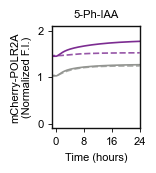

Saved Normal vs ARMC5 comparison to /Users/z3532965/src/publications/2026_POLR2A_homeostasis/Modelling/abundance_homeostasis/model_comparison_Normal_vs_ARMC5.pdf


In [12]:
# Create Normal vs ARMC5 comparison plot (RFP only, both models)

fig, ax = plt.subplots(1, 1, figsize=(1.6, 1.77))
ax.set_facecolor("white")
plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 8

# Colors: Normal = gray, ARMC5 = purple
color_normal = "#939591"
color_armc5 = "#7c2c91"

# Negative lead time
neg_times = np.linspace(-NEGATIVE_LEAD, 0, 20)

# Normal condition - Competition model
comp_traj_normal = comp_trajectories["VEH_AUX"]
A_comp_normal_0 = comp_traj_normal["A_n"][0]
A_neg_comp_normal = np.full_like(neg_times, A_comp_normal_0)
time_comp_normal = np.concatenate([neg_times, comp_traj_normal["time"]])
A_comp_normal = np.concatenate([A_neg_comp_normal, comp_traj_normal["A_n"]]) / RFP_NORM

ax.plot(
    time_comp_normal,
    A_comp_normal,
    color=color_normal,
    linewidth=1.2,
    linestyle="-",
    label="Normal (competition)",
)

# Normal condition - Feedback model
fb_traj_normal = fb_trajectories["VEH_AUX"]
A_fb_normal_0 = fb_traj_normal["A_n"][0]
A_neg_fb_normal = np.full_like(neg_times, A_fb_normal_0)
time_fb_normal = np.concatenate([neg_times, fb_traj_normal["time"]])
A_fb_normal = np.concatenate([A_neg_fb_normal, fb_traj_normal["A_n"]]) / RFP_NORM

ax.plot(
    time_fb_normal,
    A_fb_normal,
    color=color_normal,
    linewidth=1.2,
    linestyle="--",
    alpha=0.8,
    label="Normal (feedback)",
)

# ARMC5 condition - Competition model
comp_traj_armc5 = comp_trajectories_armc5["VEH_AUX"]
A_comp_armc5_0 = comp_traj_armc5["A_n"][0]
A_neg_comp_armc5 = np.full_like(neg_times, A_comp_armc5_0)
time_comp_armc5 = np.concatenate([neg_times, comp_traj_armc5["time"]])
A_comp_armc5 = np.concatenate([A_neg_comp_armc5, comp_traj_armc5["A_n"]]) / RFP_NORM

ax.plot(
    time_comp_armc5,
    A_comp_armc5,
    color=color_armc5,
    linewidth=1.2,
    linestyle="-",
    label="ARMC5 (competition)",
)

# ARMC5 condition - Feedback model
fb_traj_armc5 = fb_trajectories_armc5["VEH_AUX"]
A_fb_armc5_0 = fb_traj_armc5["A_n"][0]
A_neg_fb_armc5 = np.full_like(neg_times, A_fb_armc5_0)
time_fb_armc5 = np.concatenate([neg_times, fb_traj_armc5["time"]])
A_fb_armc5 = np.concatenate([A_neg_fb_armc5, fb_traj_armc5["A_n"]]) / RFP_NORM

ax.plot(
    time_fb_armc5,
    A_fb_armc5,
    color=color_armc5,
    linewidth=1.2,
    linestyle="--",
    alpha=0.8,
    label="ARMC5 (feedback)",
)

# Formatting
ax.set_xlim(-1, 24)
ax.set_ylim(-0.1, 2.1)
ax.set_xticks([0, 8, 16, 24])
ax.set_yticks([0.0, 1.0, 2.0])
ax.tick_params(
    axis="both", which="both", direction="out", length=3.0, width=0.6, labelsize=8
)
ax.set_title("5-Ph-IAA", fontsize=8)
ax.set_xlabel("Time (hours)", fontsize=8)
ax.set_ylabel("mCherry-POLR2A\n(Normalized F.I.)", fontsize=8)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.0)
    spine.set_color("#111111")

ax.set_xticklabels(["0", "8", "16", "24"])

fig.tight_layout()

# Save to publication path
output_armc5_path = Path("model_comparison_Normal_vs_ARMC5.pdf")
fig.savefig(output_armc5_path, bbox_inches="tight")
plt.show()

print(f"Saved Normal vs ARMC5 comparison to {output_armc5_path.resolve()}")